In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import os

from DSH import IOfunctions as iof   # <-- available on: https://github.com/steaime/DSHpy
from DSH import DLSfuncs as dlsf

import logging
logger = logging.getLogger()
logger.setLevel(logging.DEBUG)
logger = logging.getLogger('matplotlib')
logger.setLevel(logging.WARNING)
logging.info('DLS tutorial started')

INFO:root:DLS tutorial started


# Processing DLS data taken with a commercial ALV goniometer

Commercial ALV instruments ('goniometers') save data in an ASCII file with *.ASC extension. 
This tutorial shows how to read and analyze a folder in which several files correspond to multiple scans at multiple angles.
Each file has the following structure: ```prefixNNNN_MMMM.ASC```, where ```MMMM``` denotes the repetition number, from 1 to ```nrep```, while ```NNNN``` denotes the angle index (it is the same for all repetitions of the same angle, and is incremented when the angle is changed)

The function

```python
corr_fnames, unique_angleIDs, nrep = browse_folder(froot, fname_pre='', fname_ext='.ASC')
```

returns:
- ```corr_fnames```: a list of filenames corresponding to results of individual DLS experiments
- ```unique_angleIDs```: a list of unique angle IDs (can be any number, does not need to start from 0 or 1). NOTE: if during a complex procedure a given angle appears twice, the two repetitions will have different angle IDs
- ```nrep```: number of repetitions per angle, or maximum number of repetitions, in case angles have a variable number of repetitions

In [10]:
#### CHANGE THIS FOR EACH EXPERIMENT ####
froot = r'DSH\test\DLS'
fname_pre = 'DLS_200nm'
fname_ext = '.ASC'
#########################################
    
corr_fnames, unique_angleIDs, nrep = dlsf.browse_folder(froot, fname_pre, fname_ext)
print('{0} {1}*{2} files found in folder {3} ({4} angles, {5} repetitions each)'.format(len(corr_fnames), 
                                                fname_pre, fname_ext, froot, len(unique_angleIDs), nrep))

20 DLS_200nm*.ASC files found in folder DSH\test\DLS (4 angles, 5 repetitions each)


To open one single *.ASC file (reading correlation functions, intensity timetrace and metadata), use the following helper function:

```python
res = read_file(fpath, skiplines=15, corr_hdr='"Correlation"', count_hdr='"Count Rate"', key_split=':', max_count=1000, plot=False)
```

It returns a dictionnary with the following keys:
- ```'theta'```: the scattering angle, in radians
- ```'q'```: the scattering vector, in $\mu m^{-1}$
- ```'corr'```: a 5x$N$ matrix. The first column is the lagtime $\tau$, in milliseconds, then there are two columns with the correlation values $g_2(\tau)-1$
- ```'count'```: a 5x$N$ matrix. The first column is the elapsed time $t$, in seconds, then there are two columns with the count rate $I_{0, 1}(t)$ from the two detectors
- ```'plot'```: the matplotlib figure with the results

In addition, it has all keys of the initial metadata, in  particular the following useful ones: ```'Temperature [K]'```, ```'Wavelength [nm]'```, ```'Angle [°]'```, ```'MeanCR0 [kHz]'```, ```'MeanCR1 [kHz]'```

dict_keys(['Temperature [K]', 'Viscosity [cp]', 'Refractive Index', 'Wavelength [nm]', 'Angle [°]', 'Duration [s]', 'FloatDur [ms]', 'Stop TP [ms]', 'Runs', 'Mode', 'MeanCR0 [kHz]', 'MeanCR1 [kHz]', 'MeanCR2 [kHz]', 'MeanCR3 [kHz]', 'theta', 'q', 'corr', 'count', 'plot'])


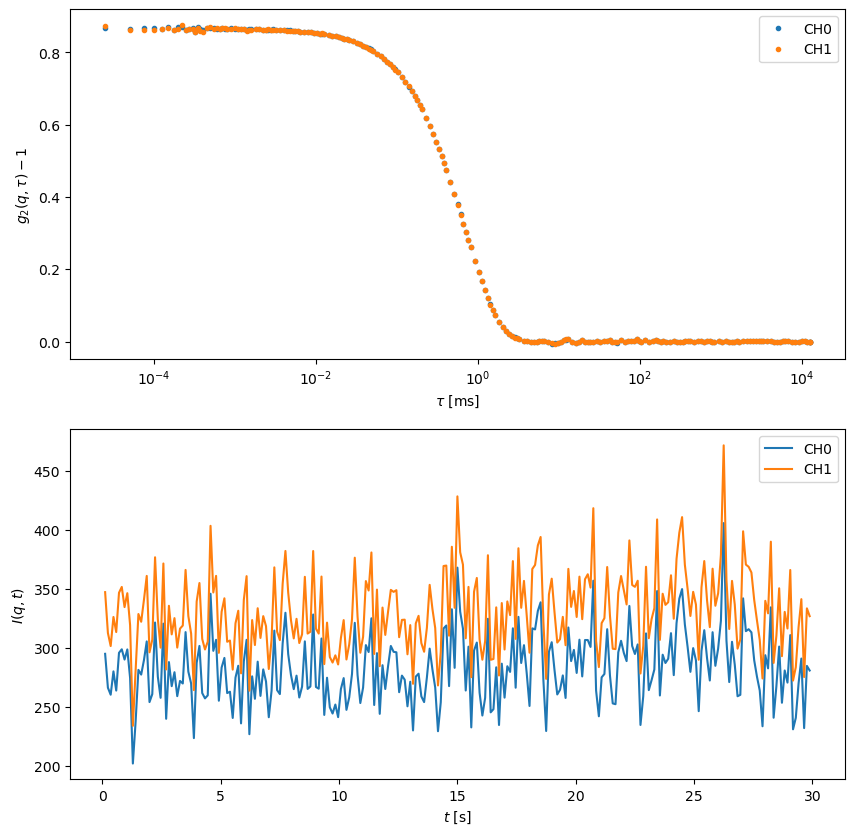

In [11]:
data = dlsf.read_file(dlsf.get_fpath(froot, unique_angleIDs[2], 3, fname_pre, fname_ext), plot=True)
print(data.keys())

To read one entire folder and combining results from different runs and angles, use the function

```python
res = merge_results(froot, fname_pre='', fname_ext='.ASC', plot=True)
```

It returns a dictionnary with the following keys. Each one is a list, one element per angle:
- ```'tau'```: a list of arrays of time delays, in milliseconds
- ```'q'```: a list of scattering vectors
- ```'avg_corr'```: average correlation function
- ```'std_corr'```: standard deviation of the correlation functions averaged
- ```'exptau'```: characteristic time of the exponential fit of $g_1(\tau)=\exp(-\tau/\tau_R)$. NOTE: measured correlation is in fact $g_2-1=g_1^2=\exp(-2\tau/\tau_R)$
- ```'expfit_corr'```: simple exponential fit prediction for $g_2-1$, evaluated at the experimental  lagtimes

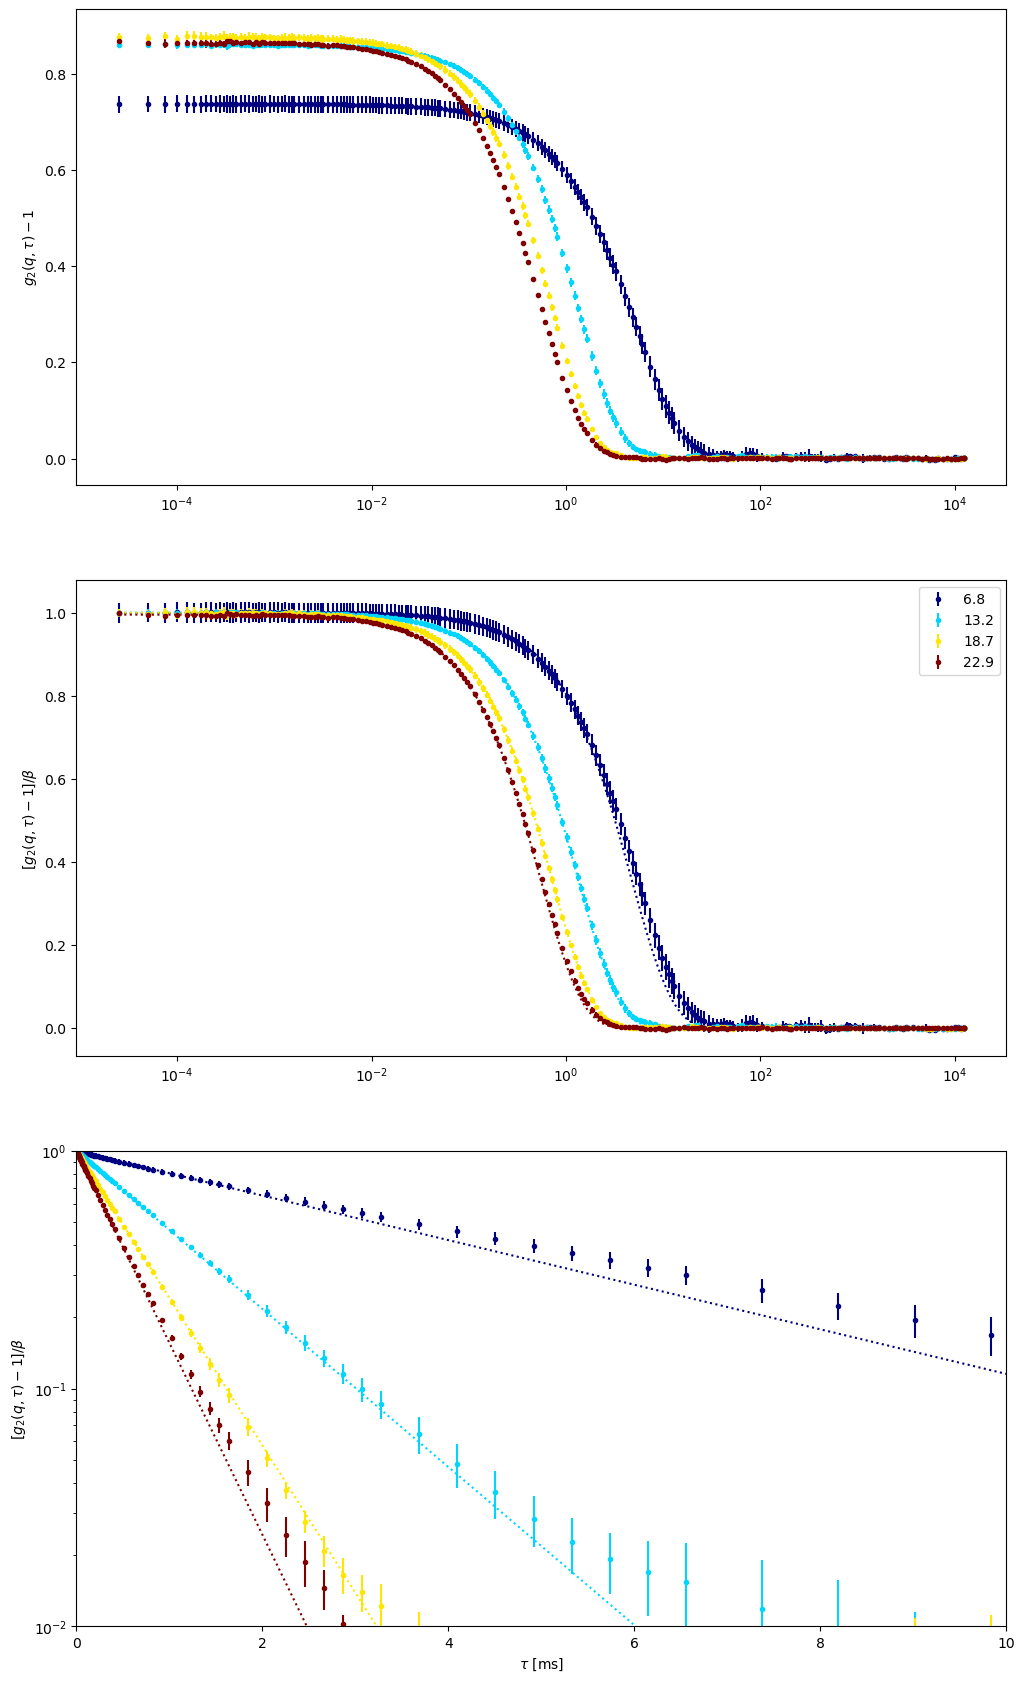

In [7]:
res = dlsf.merge_results(froot, fname_pre, fname_ext, plot=True)

For Brownian diffusion: $g_2-1 = \exp(-2Dq^2\tau)$. We extract the relaxation time by linear fiting $\ln(g_2-1)=-2Dq^2\tau$ as a function of $\tau$. 

We extract the slope $p=-2Dq^2$, and we define the relaxation time $\tau_R=-2/p=1/(Dq^2)$. 

We then extract $D$ by linear fitting $\log_{10}(\tau_R) = A+B\log_{10}(q)$, with $B=-2$. The prefactor gives us the diffusion coefficient by taking $D=10^{-A}$

Slope: -1.88. Intercept: 2.54
Fit with exponent fixed to -2: D = 2.174 um2/s


C:\Users\Student\AppData\Local\Temp\ipykernel_15008\3738857064.py:2: RuntimeWarning: invalid value encountered in log10
  return np.log10(1/(D*np.square(q)))


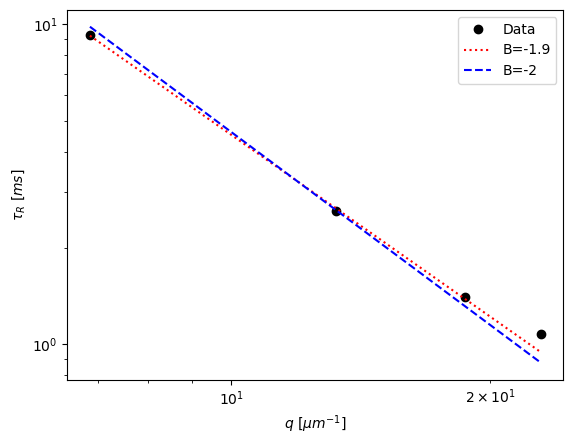

In [8]:
def logtau_q(q, D):
    return np.log10(1/(D*np.square(q)))

fit_range = slice(1, -1)
fitq = np.polyfit(np.log10(res['q'][:-1]), np.log10(res['exptau'][:-1]), 1)
iof.ExportArrays(os.path.join(froot, 'RelTimes_exp.txt'), [res['q'], res['exptau']], ['q[1/um]', 'tau[ms]'])
print('Slope: {0:.2f}. Intercept: {1:.2f}'.format(fitq[0], fitq[1]))

D_fit, cov = curve_fit(logtau_q, res['q'][:-1], np.log10(res['exptau'][:-1]))
D_fit = D_fit[0]
print('Fit with exponent fixed to -2: D = {0:.3f} um2/s'.format(D_fit*1e3))

fig, ax = plt.subplots()
ax.plot(res['q'], res['exptau'], 'ko', label='Data')
ax.plot(res['q'], 10**(np.poly1d(fitq)(np.log10(res['q']))), 'r:', label='B={0:.1f}'.format(fitq[0]))
ax.plot(res['q'], 10**(logtau_q(res['q'], D_fit)), 'b--', label='B=-2')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$q~[\mu m^{-1}]$')
ax.set_ylabel(r'$\tau_R~[ms]$')
ax.legend()

fig.savefig(os.path.join(froot, 'RelTimes_exp.png'))

Stokes Einstein: $D=k_B T/(6\pi\eta R)$

In [9]:
kB = 1.38e-23
T = data['Temperature [K]']
# If viscosity is known, extract radius
eta = 1e-3
if eta is not None:
    R = kB*T/(6*np.pi*eta*D_fit*1e-9)
    print('Hydrodynamic radius is {0:.1f} nm'.format(R*1e9))
else:
    R = 5e-7
    eta = kB*T/(6*np.pi*R*D_fit*1e-9)
    print('Viscosity is {0:.3f} Pa.s'.format(eta))

Hydrodynamic radius is 99.0 nm


**NEW**: Contin-like analysis

c:\Users\Student\Documents\Codes\DLS_analysis\DLSfuncs.py:161: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve()


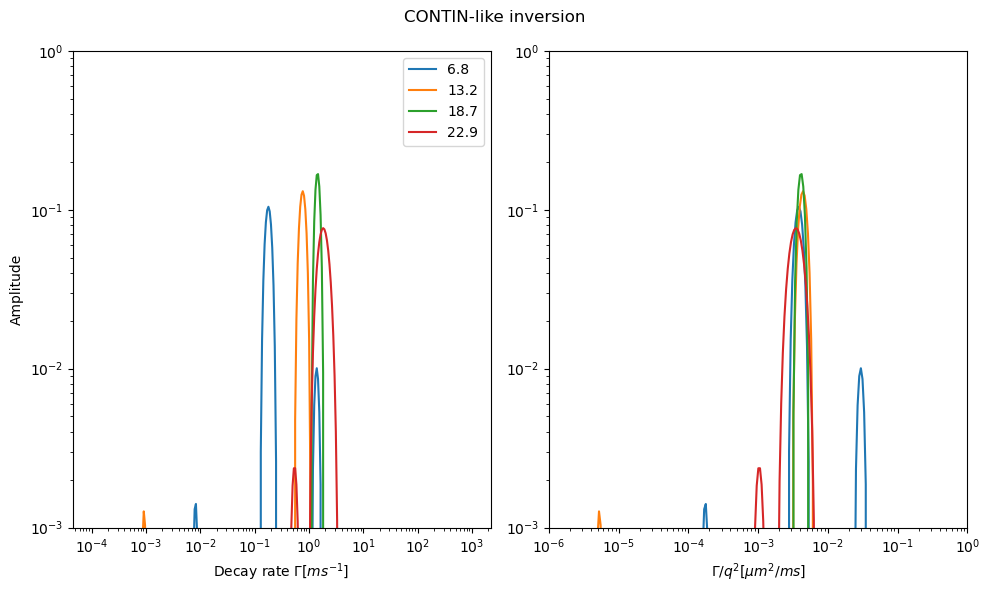

In [10]:
dist = dlsf.pseudo_contin(res, plot=True)